### Phase 1:________ Cadrage et Acquisition _________________________________________________________________________________



 ### L'objectif :Mon modèle doit prédire la note d’un étudiant en fonction de son profil socio-économique

  ### Type de problème :

     Il s’agit d’un problème de régression, car la sortie est une valeur numérique.

### Présentation du dataset
Le dataset utilisé contient des informations sur les étudiants ainsi que leurs résultats aux examens.  
Chaque ligne représente un étudiant et ses caractéristiques personnelles et académiques.

### Variable cible :
La variable cible (y) est le moyenne_generale.

### Variables explicatives :
Les variables explicatives (X) utilisées pour la prédiction sont :
- gender  
- race/ethnicity  
- parental level of education  
- lunch  
- test preparation course  
- reading score  
- writing score .

### Problématique :
Ce modèle vise à répondre à la question suivante :
L’origine socio-économique influence-t-elle les résultats scolaires ?


### Phase 2: ___________ Analyse Exploratoire (EDA)______________

### 1:Compréhension générale du dataset


In [357]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plot
import seaborn as sns
##Chargement du dataset
df_original = pd.read_csv("StudentsPerformance.csv")
df = df_original.copy()
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [358]:
df.tail()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77
999,female,group D,some college,free/reduced,none,77,86,86


In [359]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


Les résultats montrent que les notes des étudiants sont globalement moyennes.
La moyenne est autour de 66 pour les mathématiques, 69 pour la lecture et 68 pour l’écriture.

On remarque aussi que les valeurs minimales et maximales sont très différentes, ce qui veut dire qu’il y a des étudiants très faibles et d’autres très forts.

La moyenne et la médiane sont proches, donc les données sont assez équilibrées.

Mais il y a quelques valeurs très différentes des autres, ce qui peut montrer la présence de quelques outliers.

Enfin, l’écart-type est environ 15, ce qui signifie que les notes sont un peu dispersées, mais pas trop.

In [360]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


 L’analyse du dataset montre qu’il contient 1000 observations et 8 variables. 5 variables sont catégorielles et 3 sont numériques. Aucune valeur manquante n’a été détectée, ce qui indique que les données sont complètes et prêtes pour l’analyse. Les variables numériques représentent les scores des étudiants, tandis que les variables catégorielles décrivent leur profil socio-économique et académique.

### 2:Vérification des données

In [361]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

L’analyse des valeurs manquantes montre qu’il n’y a aucune donnée manquante dans le dataset.

In [362]:
df.duplicated().sum()

np.int64(0)

La vérification des doublons montre qu’il n’existe aucune ligne dupliquée dans le dataset.Cela montre que le dataset est bien organisé et ne contient pas de lignes répétées.

### 3: Distribution (Histogram)

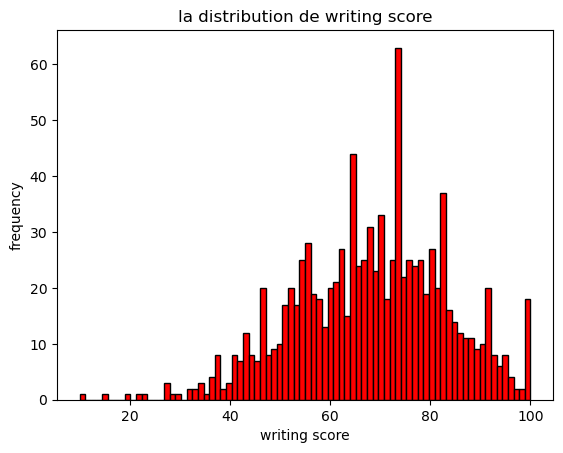

In [363]:
plot.hist(df['writing score'] , bins=80 , color='red' ,edgecolor='black')
plot.xlabel("writing score")
plot.ylabel("frequency")
plot.title("la distribution de writing score")
plot.show()

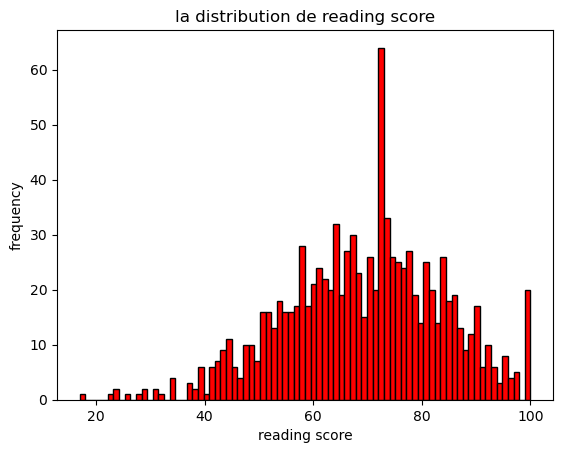

In [364]:
plot.hist(df['reading score'] , bins=80 , color='red' ,edgecolor='black')
plot.xlabel("reading score")
plot.ylabel("frequency")
plot.title("la distribution de reading score")
plot.show()

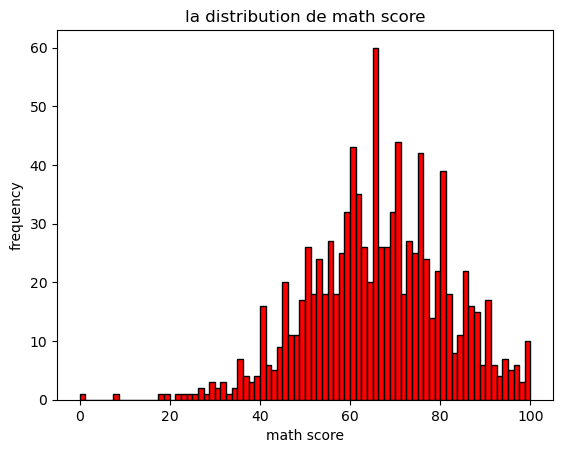

In [365]:
plot.hist(df['math score'] , bins=80 , color='red' ,edgecolor='black')
plot.xlabel("math score")
plot.ylabel("frequency")
plot.title("la distribution de math score")
plot.show()

La plupart des étudiants ont des notes entre 50 et 80 On observe un pic autour de 65, ce qui représente le score le plus fréquent. Le graphique est presque équilibré, mais on remarque une légère asymétrie vers la gauche à cause de quelques faibles notes.

In [366]:

df['math score'].skew()

np.float64(-0.27893514909431694)

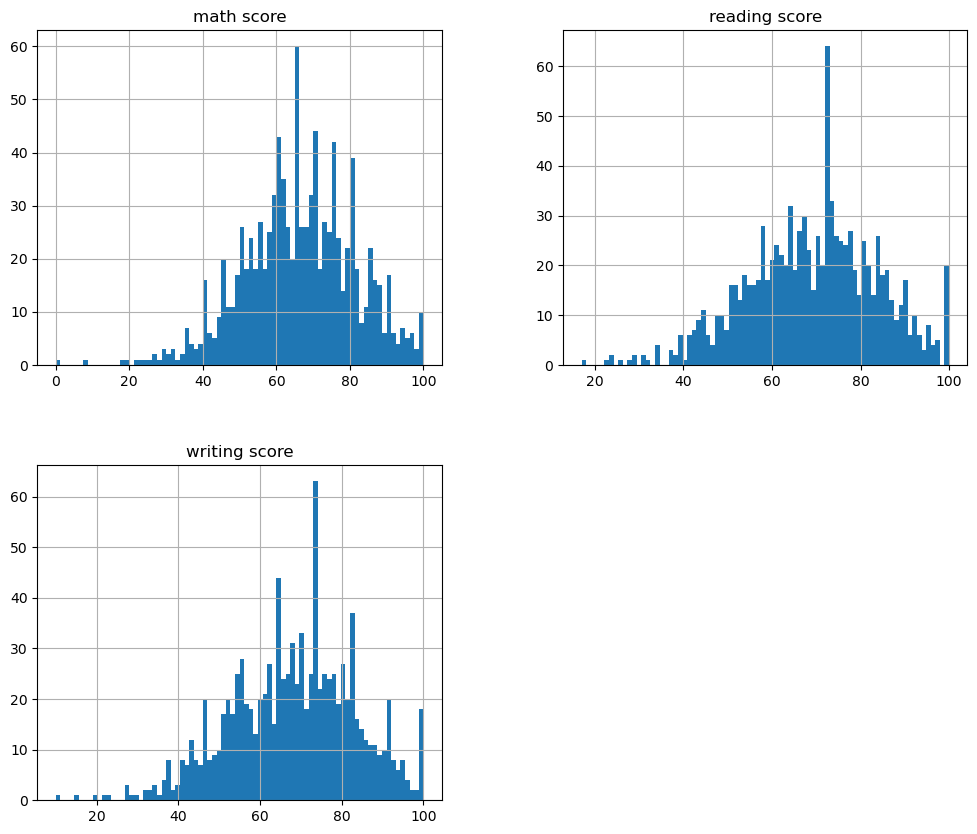

In [367]:
df.hist(figsize=(12,10), bins=80 )
plt.show()

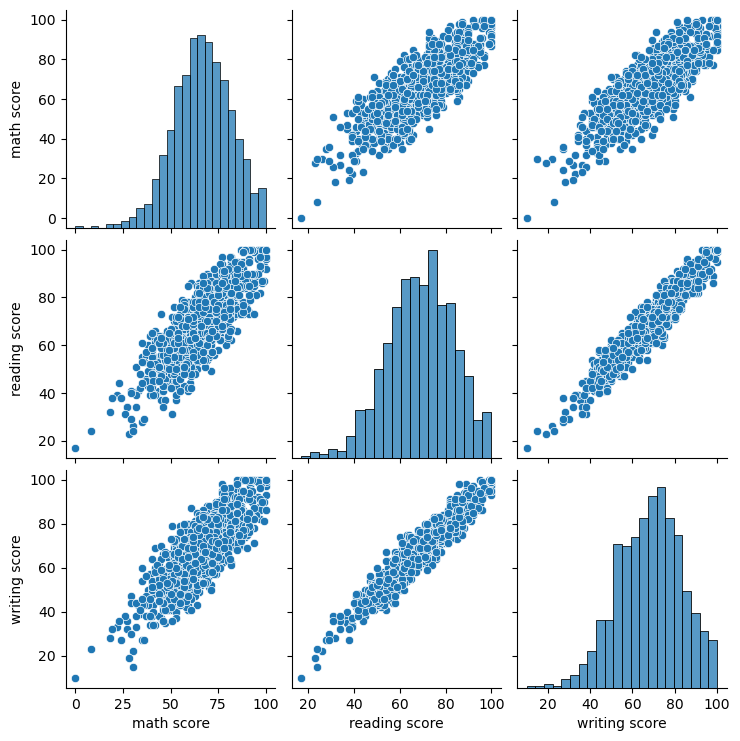

In [368]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(df.select_dtypes(include=['int64', 'float64']))
plt.show()

### 4 : Boxplots
### pour math score

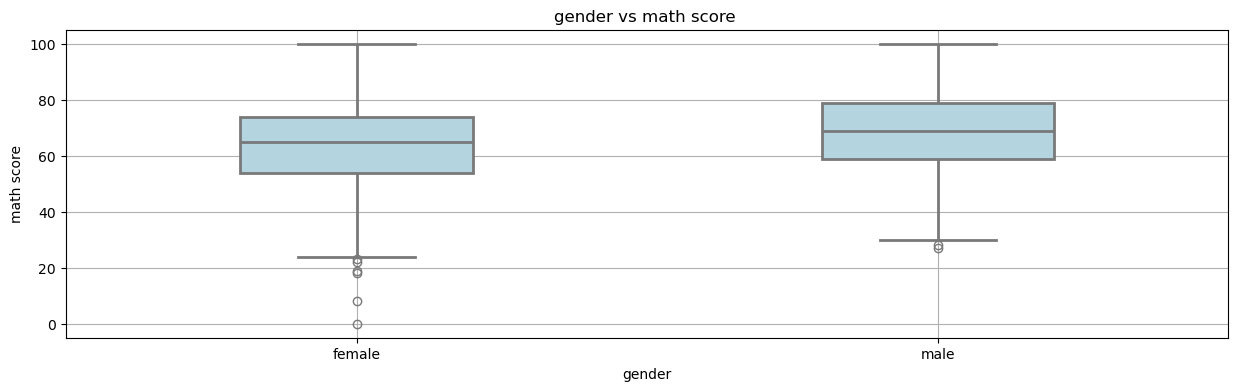

In [369]:
plot.figure(figsize=(15,4))
sns.boxplot( x="gender", y="math score" ,data = df ,color = 'lightblue' ,linewidth=2,width=0.4,orient='v')
plot.title('gender vs math score ')
plot.xlabel('gender')
plot.ylabel('math score')
plot.grid()
plot.show()

Le boxplot montre une légère différence entre les garçons et les filles dans les scores de mathématiques. La médiane des garçons est un peu plus élevée, mais la différence reste faible. On observe également quelques valeurs extrêmes représentant des étudiants avec des notes très faibles.

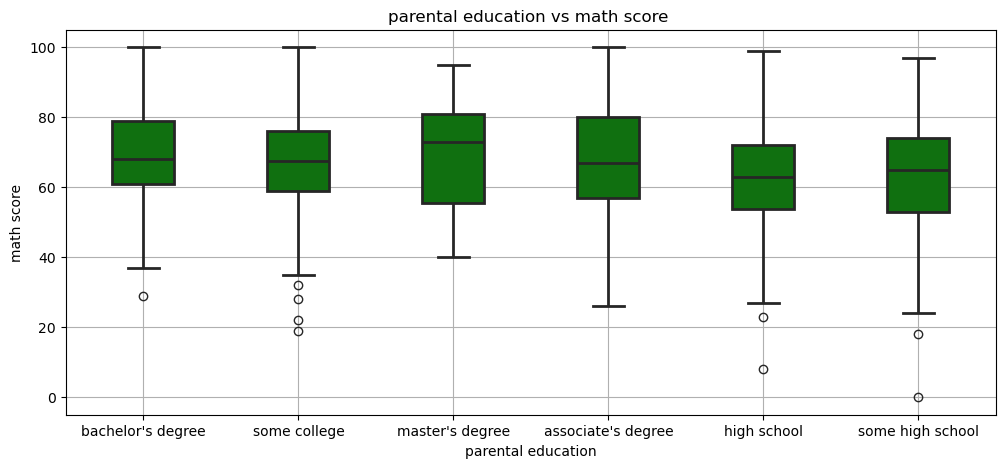

In [370]:
plot.figure(figsize=(12,5))
sns.boxplot( x="parental level of education", y="math score" ,data = df ,color = 'green' ,linewidth=2,width=0.4,orient='v')
plot.title('parental education vs math score ')
plot.xlabel('parental education')
plot.ylabel('math score')
plot.grid()
plot.show()

le boxplot montre une relation entre le niveau d’éducation des parents et les scores en mathématiques. Les élèves dont les parents ont un master obtiennent les meilleures performances (médiane ≈ 72), suivis de ceux avec un bachelor ou un associate’s degree. Les résultats les plus faibles sont observés chez les élèves dont les parents ont un niveau high school ou moins (médiane ≈ 63–64). Cela indique une tendance générale : plus le niveau d’éducation des parents est élevé, meilleurs sont les résultats en mathématiques. Toutefois, il s’agit d’une corrélation et non d’une causalité.

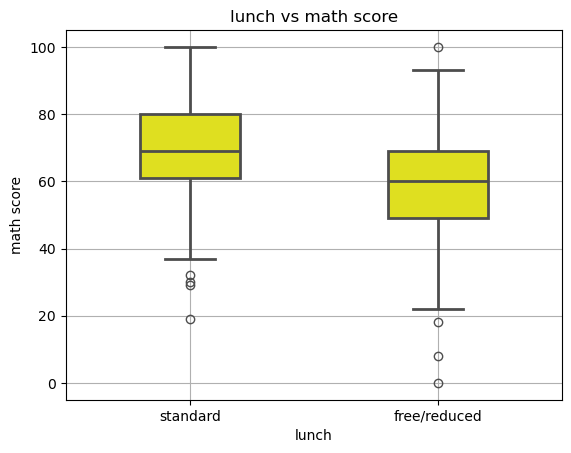

In [371]:

sns.boxplot( x="lunch", y="math score" ,data = df ,color = 'yellow' ,linewidth=2,width=0.4,orient='v')
plot.title('lunch vs math score')
plot.xlabel('lunch')
plot.ylabel('math score')
plot.grid()
plot.show()

Le diagramme en boîte montre l’impact du type de déjeuner sur les scores en mathématiques. Les élèves ayant un déjeuner standard obtiennent de meilleurs résultats, avec une médiane d’environ 70, tandis que ceux ayant un déjeuner gratuit ou réduit présentent des scores plus faibles, avec une médiane proche de 60. On observe également une légère différence dans la dispersion des notes. Cela suggère que le type de repas peut être associé à la performance scolaire, probablement en lien avec le contexte socio-économique des élèves.

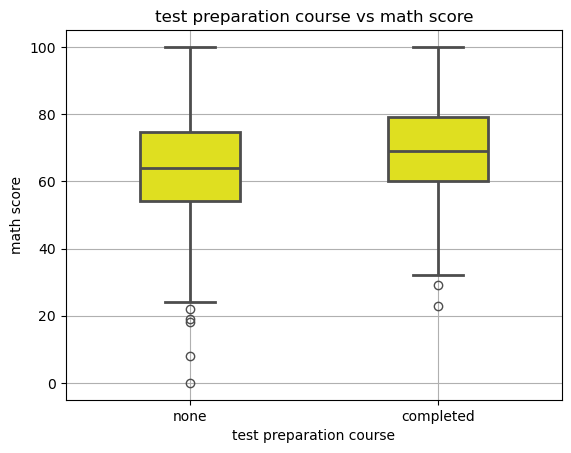

In [372]:
sns.boxplot( x="test preparation course", y="math score" ,data = df ,color = 'yellow' ,linewidth=2,width=0.4,orient='v')
plot.title('test preparation course vs math score')
plot.xlabel('test preparation course')
plot.ylabel('math score')
plot.grid()
plot.show()

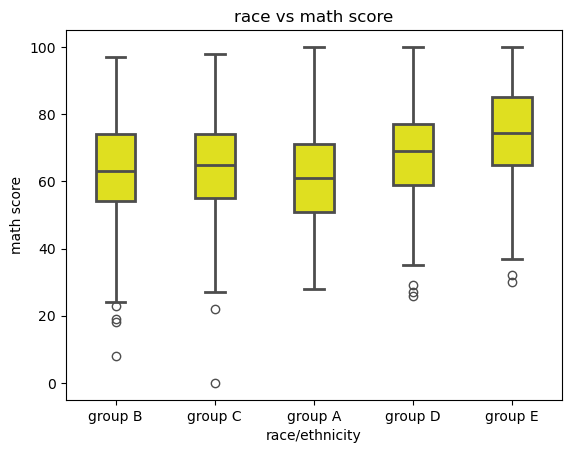

In [373]:
sns.boxplot(
    x="race/ethnicity",
    y="math score",
    data=df,
    color='yellow',
    linewidth=2,
    width=0.4,
    orient='v'
)

plot.title('race vs math score')
plot.xlabel('race/ethnicity')
plot.ylabel('math score')

plot.show()

### pour reading score

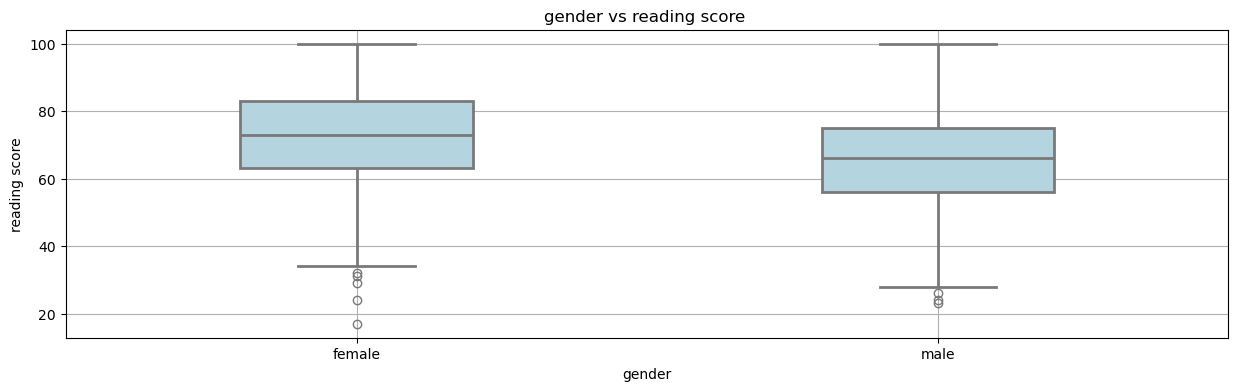

In [374]:
plot.figure(figsize=(15,4))
sns.boxplot( x="gender", y="reading score" ,data = df ,color = 'lightblue' ,linewidth=2,width=0.4,orient='v')
plot.title('gender vs reading score ')
plot.xlabel('gender')
plot.ylabel('reading score')
plot.grid()
plot.show()

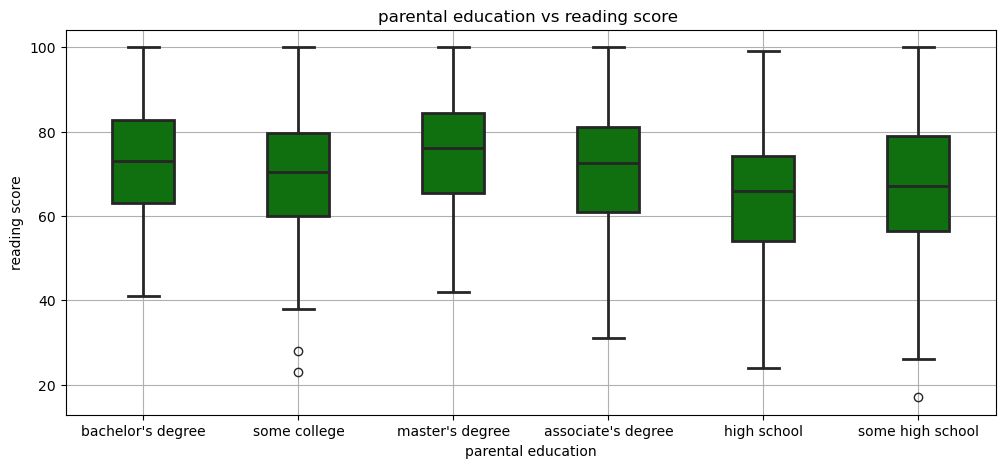

In [375]:
plot.figure(figsize=(12,5))
sns.boxplot( x="parental level of education", y="reading score" ,data = df ,color = 'green' ,linewidth=2,width=0.4,orient='v')
plot.title('parental education vs reading score ')
plot.xlabel('parental education')
plot.ylabel('reading score')
plot.grid()
plot.show()

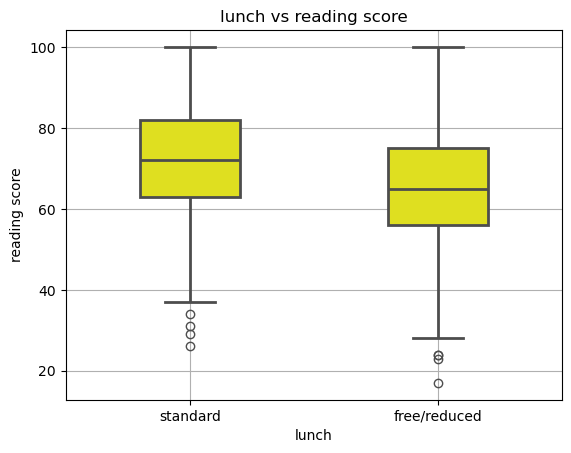

In [376]:
sns.boxplot( x="lunch", y="reading score" ,data = df ,color = 'yellow' ,linewidth=2,width=0.4,orient='v')
plot.title('lunch vs reading score')
plot.xlabel('lunch')
plot.ylabel('reading score')
plot.grid()
plot.show()

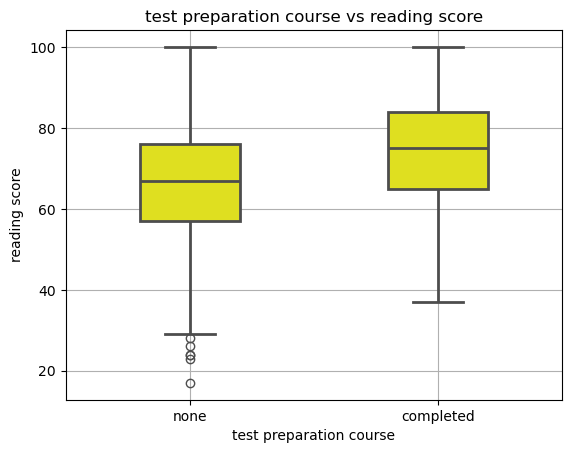

In [377]:
sns.boxplot( x="test preparation course", y="reading score" ,data = df ,color = 'yellow' ,linewidth=2,width=0.4,orient='v')
plot.title('test preparation course vs reading score')
plot.xlabel('test preparation course')
plot.ylabel('reading score')
plot.grid()
plot.show()

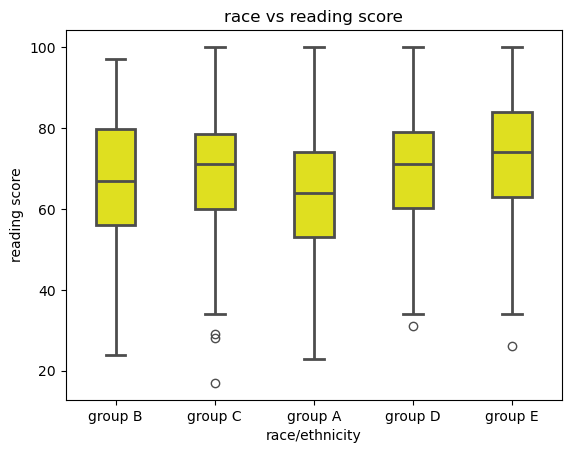

In [378]:
sns.boxplot(
    x="race/ethnicity",
    y="reading score",
    data=df,
    color='yellow',
    linewidth=2,
    width=0.4,
    orient='v'
)

plot.title('race vs reading score')
plot.xlabel('race/ethnicity')
plot.ylabel('reading score')

plot.show()

### Pour writing score

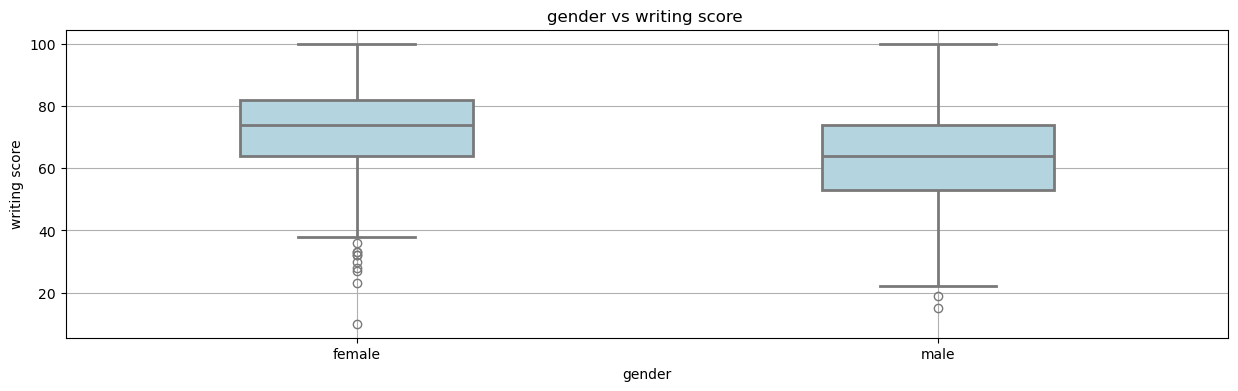

In [379]:
plot.figure(figsize=(15,4))
sns.boxplot( x="gender", y="writing score" ,data = df ,color = 'lightblue' ,linewidth=2,width=0.4,orient='v')
plot.title('gender vs writing score ')
plot.xlabel('gender')
plot.ylabel('writing score')
plot.grid()
plot.show()

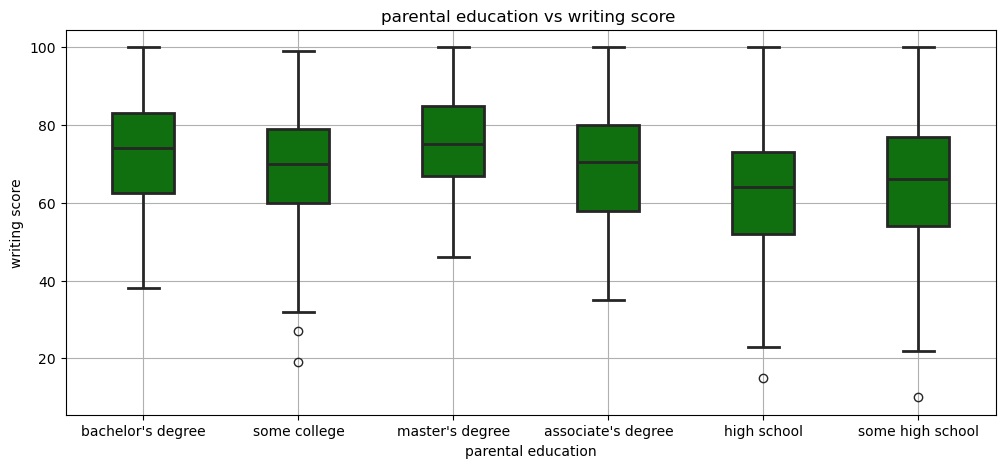

In [380]:
plot.figure(figsize=(12,5))
sns.boxplot( x="parental level of education", y="writing score" ,data = df ,color = 'green' ,linewidth=2,width=0.4,orient='v')
plot.title('parental education vs writing score ')
plot.xlabel('parental education')
plot.ylabel('writing score')
plot.grid()
plot.show()

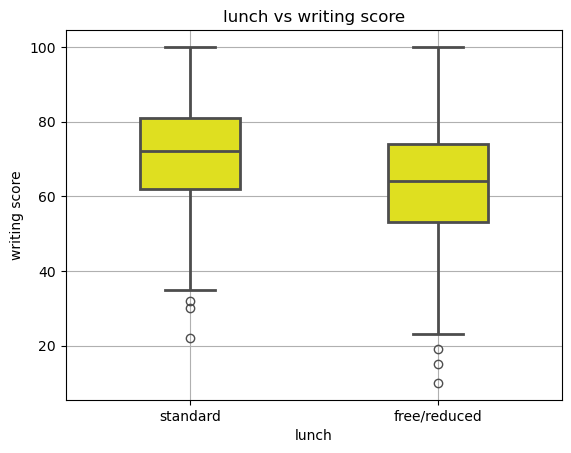

In [381]:
sns.boxplot( x="lunch", y="writing score" ,data = df ,color = 'yellow' ,linewidth=2,width=0.4,orient='v')
plot.title('lunch vs writing score')
plot.xlabel('lunch')
plot.ylabel('writing score')
plot.grid()
plot.show()

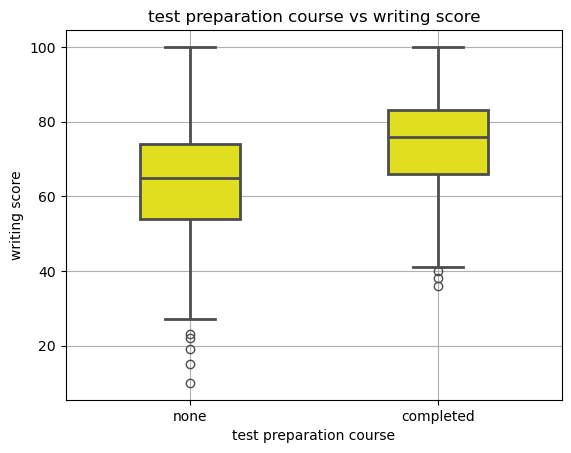

In [382]:
sns.boxplot( x="test preparation course", y="writing score" ,data = df ,color = 'yellow' ,linewidth=2,width=0.4,orient='v')
plot.title('test preparation course vs writing score')
plot.xlabel('test preparation course')
plot.ylabel('writing score')
plot.grid()
plot.show()

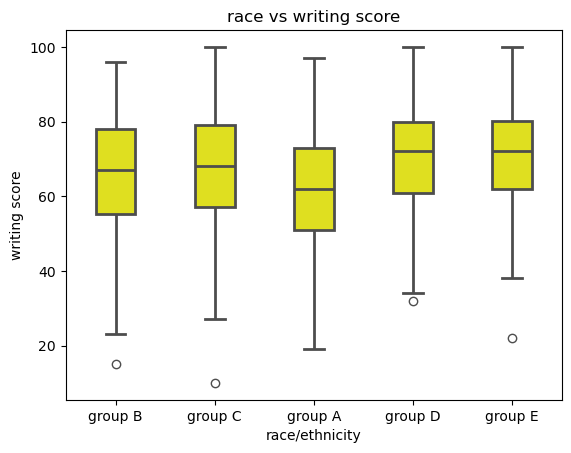

In [383]:
sns.boxplot(
    x="race/ethnicity",
    y="writing score",
    data=df,
    color='yellow',
    linewidth=2,
    width=0.4,
    orient='v'
)

plot.title('race vs writing score')
plot.xlabel('race/ethnicity')
plot.ylabel('writing score')

plot.show()

### 5 : Correlation

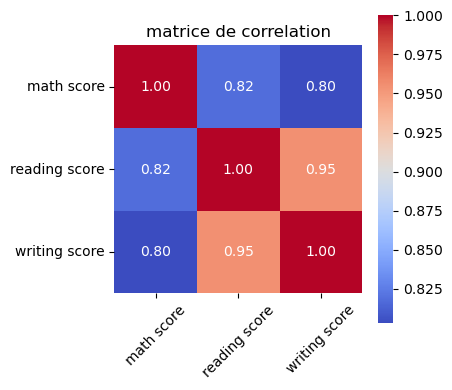

In [384]:
correlation_matrix=df.corr(numeric_only=True)
plot.figure(figsize=(4,4))
sns.heatmap(correlation_matrix, annot=True , fmt=".2f" ,cmap="coolwarm",cbar=True,square=True)
plot.title("matrice de correlation")
plot.xticks(rotation=45)
plot.yticks(rotation=0)
plot.show()

### Phase 3 : ______________ Préparation des Données____________________
### 1 :Nettoyage 

Les données ne présentent aucune valeur manquante, comme le confirme la fonction isnull() qui retourne false pour toutes les variables. Ainsi, aucune étape d’imputation ou de suppression n’a été nécessaire durant la phase de nettoyage


In [393]:
df_numeric = df.select_dtypes(include=['int64', 'float64'])

for col in df_numeric.columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    minim = Q1 - 1.5 * IQR
    maxim = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < minim) |
        (df[col] > maxim)
    ]
outliers

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
59,female,group C,some high school,free/reduced,none,0,17,10
76,male,group E,some high school,standard,none,30,26,22
327,male,group A,some college,free/reduced,none,28,23,19
596,male,group B,high school,free/reduced,none,30,24,15
980,female,group B,high school,free/reduced,none,8,24,23


In [394]:
print(len(outliers))

5


Les valeurs aberrantes détectées correspondent principalement à des élèves ayant de très faibles performances scolaires. Ces observations ne représentent pas des erreurs de données, mais plutôt des cas réels d’élèves en difficulté. Par conséquent, elles ont été conservées afin de préserver la diversité et la représentativité des données.

### 2 : Feature Engineering
2_1 : Feature Synthétique

La variable "moyenne générale" est une caractéristique synthétique obtenue par la combinaison des scores en mathématiques, lecture et écriture. Elle permet de représenter le niveau global de l'étudiant de manière plus équilibrée.

In [395]:
# Calcul de la moyenne des trois matières
df["moyenne_generale"] = (
    df["math score"] + 
    df["reading score"] + 
    df["writing score"]
) / 3

In [396]:
#Indice socio-économique
df["socio_index"] = (
    (df["lunch"] == "standard").astype(int) +
    (df["parental level of education"].isin(["bachelor's degree", "master's degree"])).astype(int)
)

2_2 :  Feature Spécifique au domaine

In [397]:
def niveau(x):
    if x >=80 :
        return "élevé"
    elif x >=60 :
        return "moyen"
    else :
        return "faible"

df["niveau_performance"]=df["moyenne_generale"].apply(niveau)

In [398]:
#
df["socio_status"] = df["socio_index"].apply(
    lambda x: "faible" if x == 0 else ("moyen" if x == 1 else "élevé")
)

In [399]:

df["parent_group"] = df["parental level of education"].apply(
    lambda x: "low" if x in ["high school", "some high school"]
    else "medium" if x == "some college"
    else "high"
)

In [400]:
df["study_level"] = df["test preparation course"].apply(
    lambda x: "révise" if x == "completed" else "négligent"
)

In [401]:
df.tail()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,moyenne_generale,socio_index,niveau_performance,socio_status,parent_group,study_level
995,female,group E,master's degree,standard,completed,88,99,95,94.000000,2,élevé,élevé,high,révise
996,male,group C,high school,free/reduced,none,62,55,55,57.333333,0,faible,faible,low,négligent
997,female,group C,high school,free/reduced,completed,59,71,65,65.000000,0,moyen,faible,low,révise
998,female,group D,some college,standard,completed,68,78,77,74.333333,1,moyen,moyen,medium,révise
999,female,group D,some college,free/reduced,none,77,86,86,83.000000,0,élevé,faible,medium,négligent


In [402]:
df.groupby("socio_index")["moyenne_generale"].mean()

socio_index
0    61.044135
1    69.507726
2    75.856269
Name: moyenne_generale, dtype: float64

### 3:Transformation :
### 1:Encodage

In [403]:
df[['gender',
    'lunch',
    'parental level of education',
    'test preparation course',
    'niveau_performance',
    'race/ethnicity',
    'parent_group',
    'study_level']].head()

,gender,lunch,parental level of education,test preparation course,niveau_performance,race/ethnicity,parent_group,study_level
0,female,standard,bachelor's degree,none,moyen,group B,high,négligent
1,female,standard,some college,completed,élevé,group C,medium,révise
2,female,standard,master's degree,none,élevé,group B,high,négligent
3,male,free/reduced,associate's degree,none,faible,group A,high,négligent
4,male,standard,some college,none,moyen,group C,medium,négligent


1_1:Label Encoding 

utilisée pour les variables ordinales:comme  "parental level of education"

In [404]:
from sklearn.preprocessing import LabelEncoder

le_parent = LabelEncoder()
le_perf = LabelEncoder()
le_group = LabelEncoder()

df["parental level of education"] = le_parent.fit_transform(df["parental level of education"])
df["niveau_performance"] = le_perf.fit_transform(df["niveau_performance"])
df["parent_group"] = le_group.fit_transform(df["parent_group"])

1_2:One-Hot

utilisée pour les variables nominales : comme gender et	lunch et test preparation course...

In [405]:
df = pd.get_dummies(df,
                    columns=["gender",
                             "race/ethnicity",
                             "lunch",
                             "test preparation course","study_level","parental level of education"],drop_first=True)

In [406]:
df.tail()

,math score,reading score,writing score,moyenne_generale,socio_index,niveau_performance,socio_status,parent_group,gender_male,race/ethnicity_group B,...,race/ethnicity_group D,race/ethnicity_group E,lunch_standard,test preparation course_none,study_level_révise,parental level of education_1,parental level of education_2,parental level of education_3,parental level of education_4,parental level of education_5
995,88,99,95,94.000000,2,2,élevé,0,False,False,...,False,True,True,False,True,False,False,True,False,False
996,62,55,55,57.333333,0,0,faible,1,True,False,...,False,False,False,True,False,False,True,False,False,False
997,59,71,65,65.000000,0,1,faible,1,False,False,...,False,False,False,False,True,False,True,False,False,False
998,68,78,77,74.333333,1,1,moyen,2,False,False,...,True,False,True,False,True,False,False,False,True,False
999,77,86,86,83.000000,0,2,faible,2,False,False,...,True,False,False,True,False,False,False,False,True,False


In [407]:
print(df.columns)

Index(['math score', 'reading score', 'writing score', 'moyenne_generale',
       'socio_index', 'niveau_performance', 'socio_status', 'parent_group',
       'gender_male', 'race/ethnicity_group B', 'race/ethnicity_group C',
       'race/ethnicity_group D', 'race/ethnicity_group E', 'lunch_standard',
       'test preparation course_none', 'study_level_révise',
       'parental level of education_1', 'parental level of education_2',
       'parental level of education_3', 'parental level of education_4',
       'parental level of education_5'],
      dtype='object')


### 4:Scaling  et Split 


Normaliser les données (StandardScaler) pour que toutes les variables aient le même poids.
Séparer impérativement les données en Train set (80%) et Test set (20%).

In [408]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

scaler = StandardScaler()

features = [
    'niveau_performance',
       'socio_index',
    'parent_group', 
    'gender_male',
       'race/ethnicity_group B',
    'race/ethnicity_group C',
       'race/ethnicity_group D',
    'race/ethnicity_group E', 
    'study_level_révise',
       
]
X = df[features].copy()
y=df['moyenne_generale']

X_train, X_test, y_train, y_test = train_test_split(
   X, y,
    test_size=0.2,
    random_state=42)

# Scaling
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=features)

X_test_scaled = pd.DataFrame(X_test_scaled, columns=features)
X_train_scaled.head()

,niveau_performance,socio_index,parent_group,gender_male,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,study_level_révise
0,0.100764,1.940601,-1.065626,-0.948808,-0.486288,-0.693889,1.720580,-0.411814,-0.731785
1,0.100764,0.278416,-1.065626,-0.948808,-0.486288,1.441153,-0.581199,-0.411814,1.366522
2,1.540246,-1.383769,1.517709,-0.948808,-0.486288,-0.693889,1.720580,-0.411814,-0.731785
3,0.100764,0.278416,-1.065626,1.053953,-0.486288,1.441153,-0.581199,-0.411814,-0.731785
4,0.100764,0.278416,0.226042,1.053953,-0.486288,-0.693889,-0.581199,2.428282,-0.731785


In [409]:
X_test_scaled.head()

,niveau_performance,socio_index,parent_group,gender_male,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,study_level_révise
0,1.540246,0.278416,-1.065626,-0.948808,-0.486288,1.441153,-0.581199,-0.411814,-0.731785
1,0.100764,-1.383769,1.517709,-0.948808,2.056394,-0.693889,-0.581199,-0.411814,1.366522
2,0.100764,1.940601,-1.065626,1.053953,-0.486288,-0.693889,1.720580,-0.411814,-0.731785
3,0.100764,-1.383769,1.517709,1.053953,-0.486288,1.441153,-0.581199,-0.411814,-0.731785
4,1.540246,0.278416,1.517709,1.053953,-0.486288,-0.693889,-0.581199,2.428282,1.366522


In [410]:

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Train shape: (800, 9) Test shape: (200, 9)


### Phase 4 : ___________Modélisation et Entraînement ______________

Création des modèles
### 1:Modèle Baseline

Nous avons utilisé un modèle baseline simple : Linear Regression
Le modèle a été entraîné sur le jeu d’entraînement puis utilisé pour effectuer des prédictions sur le jeu de test

In [411]:
from sklearn.linear_model import LinearRegression
model_linear = LinearRegression()
# Entraînement
model_linear.fit(X_train, y_train)
# Prédictions
pred_linear  = model_linear.predict(X_test)

### 2 :Modèles Complexes svm et Random Forest

In [412]:
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
model_svr = SVR(kernel='linear')
# Entraînement
model_svr.fit(X_train_scaled, y_train)
# Prédictions
pred_svr = model_svr.predict(X_test_scaled)
model_rf = RandomForestRegressor(
    n_estimators=1000,
    random_state=42
)
# Entraînement
model_rf.fit(X_train, y_train)
# Prédictions
pred_rf = model_rf.predict(X_test_scaled)

### 3:Validation Croisée (Cross-Validation)

In [413]:
#pour modele simple 
from sklearn.model_selection import cross_val_score
# Cross-Validation
scores = cross_val_score(
    model_linear,
    X_train,
    y_train,
    cv=5,
    scoring='r2'
)

# Résultats
print("Scores R2 pour chaque fold :", scores)
print("Moyenne R2 :", scores.mean())
print("Écart-type :", scores.std())

Scores R2 pour chaque fold : [0.8285357  0.84557588 0.7902593  0.84053812 0.79039601]
Moyenne R2 : 0.8190610022699059
Écart-type : 0.024105165859254013


In [414]:
X_train.head()

,niveau_performance,socio_index,parent_group,gender_male,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,study_level_révise
29,1,2,0,False,False,False,True,False,False
535,1,1,0,False,False,True,False,False,True
695,2,0,2,False,False,False,True,False,False
557,1,1,0,True,False,True,False,False,False
836,1,1,1,True,False,False,False,True,False


In [415]:
#pour modele svm

scores_svm = cross_val_score(
   model_svr,
    X_train,
    y_train,
    cv=5,
    scoring='r2'
)


print("Scores R2 pour chaque fold :", scores_svm)
print("Moyenne R2 :", scores_svm.mean())
print("Écart-type :", scores_svm.std())

Scores R2 pour chaque fold : [0.81486895 0.843494   0.7945214  0.83013803 0.77406219]
Moyenne R2 : 0.8114169161773461
Écart-type : 0.02478777732096103


In [416]:
#pour modele Random Forest
scores2 = cross_val_score(
    model_rf,
    X_train,
    y_train,
    cv=5,
    scoring='r2'
)


print("Scores R2 pour chaque fold :", scores2)
print("Moyenne R2 :", scores2.mean())
print("Écart-type :", scores2.std())

Scores R2 pour chaque fold : [0.76265641 0.8172948  0.76430535 0.8230863  0.74543528]
Moyenne R2 : 0.7825556276934764
Écart-type : 0.031484971625556045


In [417]:
#df[['niveau_performance', 'moyenne_generale']].corr()

### Phase 5 :Évaluation et Interprétation 

In [418]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def afficher_resultats(nom, y_pred):
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    print(f"{nom:20} → MAE: {mae:.2f}   RMSE: {rmse:.2f}   R²: {r2:.4f}")

In [419]:
print("=== RÉSULTATS MODELES ===\n")

afficher_resultats("Linear Regression", pred_linear)
afficher_resultats("svm", pred_svr)
afficher_resultats("Random Forest", pred_rf)


=== RÉSULTATS MODELES ===

Linear Regression    → MAE: 5.31   RMSE: 7.20   R²: 0.7581
svm                  → MAE: 5.32   RMSE: 7.43   R²: 0.7428
Random Forest        → MAE: 13.23   RMSE: 16.21   R²: -0.2256


### autre modéle

In [420]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet

# Ridge
model_ridge = Ridge(alpha=1.0)
model_ridge.fit(X_train_scaled, y_train)
pred_ridge = model_ridge.predict(X_test_scaled)

# Lasso
model_lasso = Lasso(alpha=0.01)
model_lasso.fit(X_train_scaled, y_train)
pred_lasso = model_lasso.predict(X_test_scaled)

# ElasticNet
model_enet = ElasticNet(alpha=0.01, l1_ratio=0.5)
model_enet.fit(X_train_scaled, y_train)
pred_enet = model_enet.predict(X_test_scaled)

In [421]:
afficher_resultats("Ridge", pred_ridge)
afficher_resultats("Lasso", pred_lasso)
afficher_resultats("ElasticNet", pred_enet)

Ridge                → MAE: 5.31   RMSE: 7.20   R²: 0.7580
Lasso                → MAE: 5.31   RMSE: 7.20   R²: 0.7581
ElasticNet           → MAE: 5.31   RMSE: 7.21   R²: 0.7577


In [424]:
errors = y_test - pred_linear
errors

521    -0.293324
737    -3.477538
740     3.699992
660     8.214863
411    -6.320887
         ...    
408     2.250942
332     3.485931
208    11.044824
613     2.052136
78     -3.060437
Name: moyenne_generale, Length: 200, dtype: float64

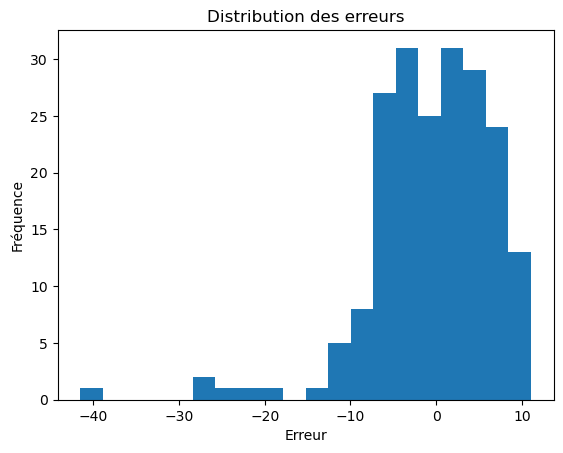

In [425]:


plt.hist(errors, bins=20)
plt.title("Distribution des erreurs")
plt.xlabel("Erreur")
plt.ylabel("Fréquence")
plt.show()

In [432]:


df_errors = pd.DataFrame({
    "Réel": y_test,
    "Prédit": pred_rf,
    "Erreur": errors
})

df_errors.sort_values("Erreur", ascending=False).head()

,Réel,Prédit,Erreur
208,77.000000,39.797552,11.044824
859,77.333333,54.091033,10.664092
678,78.000000,52.312720,10.631829
210,79.333333,49.622499,10.551519
294,78.333333,49.622499,9.551519
